In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('/content/drive/MyDrive/Monry/Academico/UANL/FCFM/A_Num/COVID19MEXICO2020.csv')

/tmp/ipykernel_875/1206878620.py:5: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('/content/drive/MyDrive/Monry/Academico/UANL/FCFM/A_Num/COVID19MEXICO2020.csv')


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3868396 entries, 0 to 3868395
Data columns (total 40 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   FECHA_ACTUALIZACION    object
 1   ID_REGISTRO            object
 2   ORIGEN                 int64 
 3   SECTOR                 int64 
 4   ENTIDAD_UM             int64 
 5   SEXO                   int64 
 6   ENTIDAD_NAC            int64 
 7   ENTIDAD_RES            int64 
 8   MUNICIPIO_RES          int64 
 9   TIPO_PACIENTE          int64 
 10  FECHA_INGRESO          object
 11  FECHA_SINTOMAS         object
 12  FECHA_DEF              object
 13  INTUBADO               int64 
 14  NEUMONIA               int64 
 15  EDAD                   int64 
 16  NACIONALIDAD           int64 
 17  EMBARAZO               int64 
 18  HABLA_LENGUA_INDIG     int64 
 19  INDIGENA               int64 
 20  DIABETES               int64 
 21  EPOC                   int64 
 22  ASMA                   int64 
 23  INMUSUP

In [ ]:
dataset_limpio = dataset.drop(columns=[
    "ID_REGISTRO","ORIGEN","SECTOR","EDAD","NACIONALIDAD",
    "SEXO","TIPO_PACIENTE","INTUBADO","NEUMONIA","EMBARAZO",
    "HABLA_LENGUA_INDIG","INDIGENA","DIABETES","EPOC","ASMA",
    "INMUSUPR","HIPERTENSION","OTRA_COM","CARDIOVASCULAR",
    "OBESIDAD","RENAL_CRONICA","TABAQUISMO","OTRO_CASO",
    "TOMA_MUESTRA_LAB","TOMA_MUESTRA_ANTIGENO","MIGRANTE",
    "PAIS_NACIONALIDAD","PAIS_ORIGEN"
], errors='ignore')

In [ ]:
dataset_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3868396 entries, 0 to 3868395
Data columns (total 12 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   FECHA_ACTUALIZACION  object
 1   ENTIDAD_UM           int64 
 2   ENTIDAD_NAC          int64 
 3   ENTIDAD_RES          int64 
 4   MUNICIPIO_RES        int64 
 5   FECHA_INGRESO        object
 6   FECHA_SINTOMAS       object
 7   FECHA_DEF            object
 8   RESULTADO_LAB        int64 
 9   RESULTADO_ANTIGENO   int64 
 10  CLASIFICACION_FINAL  int64 
 11  UCI                  int64 
dtypes: int64(8), object(4)
memory usage: 354.2+ MB


In [ ]:
dataset_NL = dataset_limpio[
    (dataset_limpio["ENTIDAD_UM"] == 19) &
    (dataset_limpio["ENTIDAD_RES"] == 19) &
    (dataset_limpio["CLASIFICACION_FINAL"].isin([1,2,3]))
].copy()

dataset_NL["FECHA_SINTOMAS"] = pd.to_datetime(
    dataset_NL["FECHA_SINTOMAS"]
)

dataset_NL["FECHA_DEF"] = pd.to_datetime(
    dataset_NL["FECHA_DEF"],
    errors='coerce'
)

/tmp/ipykernel_875/910293850.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset_NL["FECHA_DEF"] = pd.to_datetime(


In [ ]:
dataset_NL.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87499 entries, 36 to 3868233
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   FECHA_ACTUALIZACION  87499 non-null  object        
 1   ENTIDAD_UM           87499 non-null  int64         
 2   ENTIDAD_NAC          87499 non-null  int64         
 3   ENTIDAD_RES          87499 non-null  int64         
 4   MUNICIPIO_RES        87499 non-null  int64         
 5   FECHA_INGRESO        87499 non-null  object        
 6   FECHA_SINTOMAS       87499 non-null  datetime64[ns]
 7   FECHA_DEF            7073 non-null   datetime64[ns]
 8   RESULTADO_LAB        87499 non-null  int64         
 9   RESULTADO_ANTIGENO   87499 non-null  int64         
 10  CLASIFICACION_FINAL  87499 non-null  int64         
 11  UCI                  87499 non-null  int64         
dtypes: datetime64[ns](2), int64(8), object(2)
memory usage: 8.7+ MB


In [ ]:
# =========================================================
# 3. CASOS Y MUERTES DIARIAS
# =========================================================

casos_diarios = dataset_NL.groupby("FECHA_SINTOMAS").size()

muertes_diarias = dataset_NL[
    dataset_NL["FECHA_DEF"].notna()
].groupby("FECHA_DEF").size()

casos_diarios.head()


,0
FECHA_SINTOMAS,
2020-03-02,2
2020-03-04,1
2020-03-05,1
2020-03-06,1
2020-03-07,2


In [ ]:
muertes_diarias.head()

,0
FECHA_DEF,
2020-04-03,2
2020-04-05,1
2020-04-07,2
2020-04-13,1
2020-04-16,1


In [ ]:
# =========================================================
# 4. CALENDARIO CONTINUO
# =========================================================

fechas = pd.date_range(
    start=casos_diarios.index.min(),
    end=casos_diarios.index.max()
)

casos = casos_diarios.reindex(fechas, fill_value=0)
muertes = muertes_diarias.reindex(fechas, fill_value=0)
casos.head()

,0
2020-03-02,2
2020-03-03,0
2020-03-04,1
2020-03-05,1
2020-03-06,1


In [ ]:
muertes.head()

,0
2020-03-02,0
2020-03-03,0
2020-03-04,0
2020-03-05,0
2020-03-06,0


In [ ]:
# =========================================================
# 5. INFECTADOS ACTIVOS (MUCHO MÁS ESTABLE)
# =========================================================

# Aproximación:
# infectados activos = casos de los últimos 14 días

I_real = casos.rolling(window=25, min_periods=1).sum()

# Muertes acumuladas
D_real = muertes.cumsum()

I_real.head()

,0
2020-03-02,2.0
2020-03-03,2.0
2020-03-04,3.0
2020-03-05,4.0
2020-03-06,5.0


In [ ]:
D_real.head()

,0
2020-03-02,0
2020-03-03,0
2020-03-04,0
2020-03-05,0
2020-03-06,0


In [ ]:
# =========================================================
# 6. PARÁMETROS INICIALES
# =========================================================

N = 5_784_442  # población NL 2020 (Obtenido de https://www.gob.mx/salud/documentos/datos-abiertos-152127?utm_source=chatgpt.com)

fecha_inicio = fechas[0]

I0 = I_real.iloc[0]
R0 = 0
D0 = D_real.iloc[0]
S0 = N - I0 - R0 - D0

In [ ]:
# =========================================================
# 7. MODELO SIRD
# =========================================================

def derivadas(y, beta, gamma, mu, N):

    S, I, R, D = y

    dS = -beta * S * I / N

    dI = beta * S * I / N - (gamma + mu) * I

    dR = gamma * I

    dD = mu * I

    return np.array([dS, dI, dR, dD])

In [ ]:
# =========================================================
# 8. RUNGE-KUTTA ORDEN 4
# =========================================================

def rk4_sird(beta, gamma, mu,
             S0, I0, R0, D0,
             N, t_max, dt):

    n_steps = int(t_max / dt)

    tiempos = np.linspace(0, t_max, n_steps)

    solucion = np.zeros((n_steps, 4))

    y = np.array([S0, I0, R0, D0], dtype=float)

    solucion[0] = y

    for i in range(n_steps - 1):

        k1 = derivadas(y, beta, gamma, mu, N)

        k2 = derivadas(
            y + dt/2 * k1,
            beta, gamma, mu, N
        )

        k3 = derivadas(
            y + dt/2 * k2,
            beta, gamma, mu, N
        )

        k4 = derivadas(
            y + dt * k3,
            beta, gamma, mu, N
        )

        y = y + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

        y = np.maximum(y, 0)

        solucion[i+1] = y

    return (
        tiempos,
        solucion[:,0],
        solucion[:,1],
        solucion[:,2],
        solucion[:,3]
    )

In [ ]:
# =========================================================
# 9. FUNCIÓN DE ERROR
# =========================================================

t_max = len(fechas)

dt = 1.0

def error(params):

    beta, gamma, mu = params

    # Evitar parámetros negativos
    if beta < 0 or gamma < 0 or mu < 0:
        return np.inf

    t, S, I, R, D = rk4_sird(
        beta, gamma, mu,
        S0, I0, R0, D0,
        N, t_max, dt
    )

    # Ajustar tamaños
    I_model = I[:len(I_real)]

    D_model = D[:len(D_real)]

    # Error cuadrático medio
    error_I = np.mean(
        (I_real.values - I_model)**2
    )

    error_D = np.mean(
        (D_real.values - D_model)**2
    )

    # Dar más peso a muertes
    return error_I + 10 * error_D

In [ ]:
from scipy.optimize import minimize

# =========================================================
# 10. OPTIMIZACIÓN
# =========================================================

parametros_iniciales = [
    0.1,    # beta
    1/15,    # gamma
    0.005    # mu
]

limites = [
    (0.01, 1.0),
    (0.01, 1.0),
    (0.0001, 0.05)
]

resultado = minimize(
    error,
    parametros_iniciales,
    bounds=limites,
    method='L-BFGS-B'
)

beta_opt, gamma_opt, mu_opt = resultado.x

print("\nPARÁMETROS ÓPTIMOS\n")

print(f"beta  = {beta_opt:.5f}")
print(f"gamma = {gamma_opt:.5f}")
print(f"mu    = {mu_opt:.5f}")


PARÁMETROS ÓPTIMOS

beta  = 0.64584
gamma = 0.59555
mu    = 0.00543


In [ ]:
# =========================================================
# 11. SIMULACIÓN FINAL
# =========================================================

t, S, I, R, D = rk4_sird(
    beta_opt,
    gamma_opt,
    mu_opt,
    S0, I0, R0, D0,
    N,
    t_max,
    dt
)

t, S_b, I_b, R_b, D_b = rk4_sird(
    0.1,
    1/15,
    0.005,
    S0, I0, R0, D0,
    N,
    t_max,
    dt
)

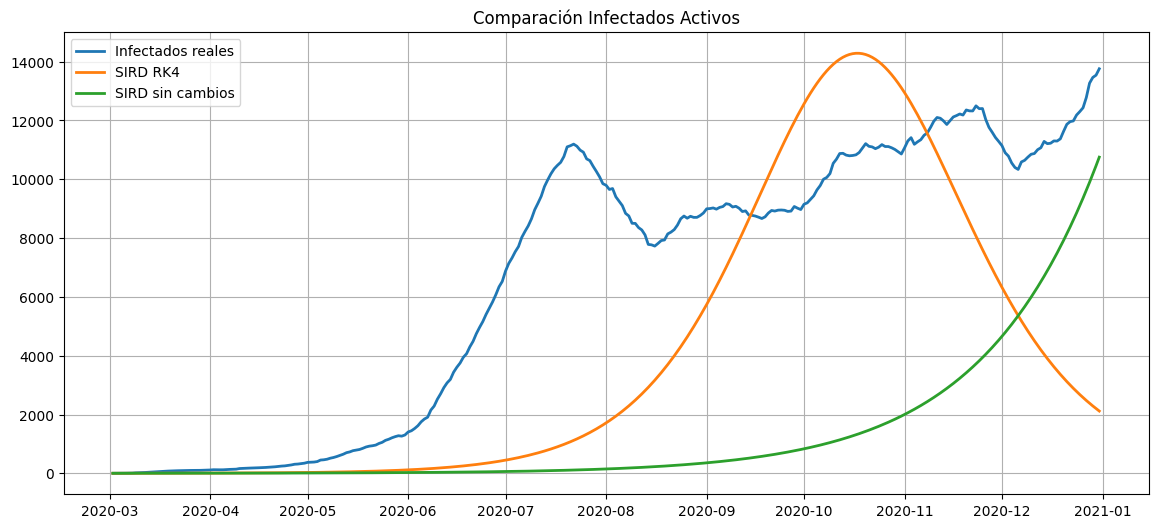

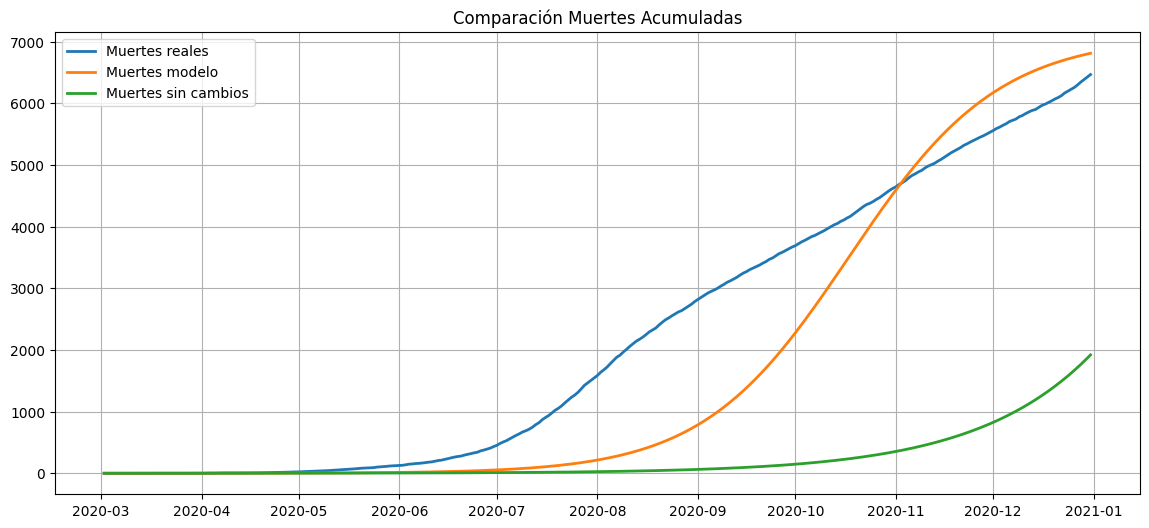

In [ ]:
# =========================================================
# 12. GRÁFICAS
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    fechas,
    I_real,
    label="Infectados reales",
    linewidth=2
)

plt.plot(
    fechas,
    I,
    label="SIRD RK4",
    linewidth=2
)

plt.plot(
    fechas,
    I_b,
    label="SIRD sin cambios",
    linewidth=2
)

plt.legend()

plt.title("Comparación Infectados Activos")

plt.grid()

plt.show()

# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    fechas,
    D_real,
    label="Muertes reales",
    linewidth=2
)

plt.plot(
    fechas,
    D,
    label="Muertes modelo",
    linewidth=2
)

plt.plot(
    fechas,
    D_b,
    label="Muertes sin cambios",
    linewidth=2
)

plt.legend()

plt.title("Comparación Muertes Acumuladas")

plt.grid()

plt.show()



In [ ]:
I_real = casos.rolling(window=25, min_periods=1).sum()
D_real = muertes.cumsum()

In [ ]:
# =========================================================
# SIRD REALES
# =========================================================

# Recuperados aproximados:
# casos acumulados - infectados activos - muertos

casos_acumulados = casos.cumsum()

R_real = (
    casos_acumulados
    - I_real
    - D_real
)

R_real = R_real.clip(lower=0)

# Susceptibles reales

S_real = (
    N
    - I_real
    - R_real
    - D_real
)

S_real = S_real.clip(lower=0)

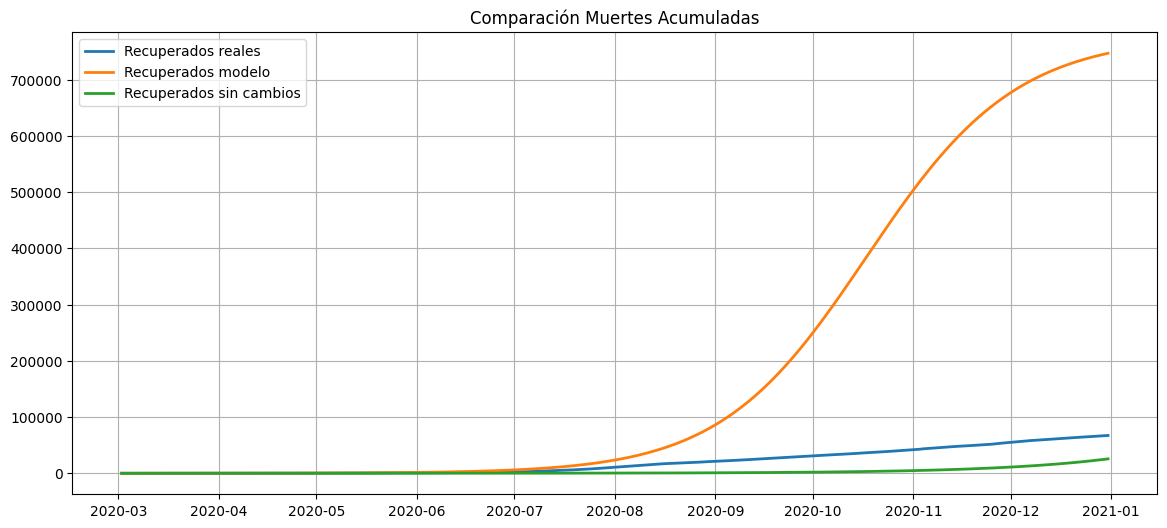

In [ ]:
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    fechas,
    R_real,
    label="Recuperados reales",
    linewidth=2
)

plt.plot(
    fechas,
    R,
    label="Recuperados modelo",
    linewidth=2
)

plt.plot(
    fechas,
    R_b,
    label="Recuperados sin cambios",
    linewidth=2
)

plt.legend()

plt.title("Comparación Muertes Acumuladas")

plt.grid()

plt.show()

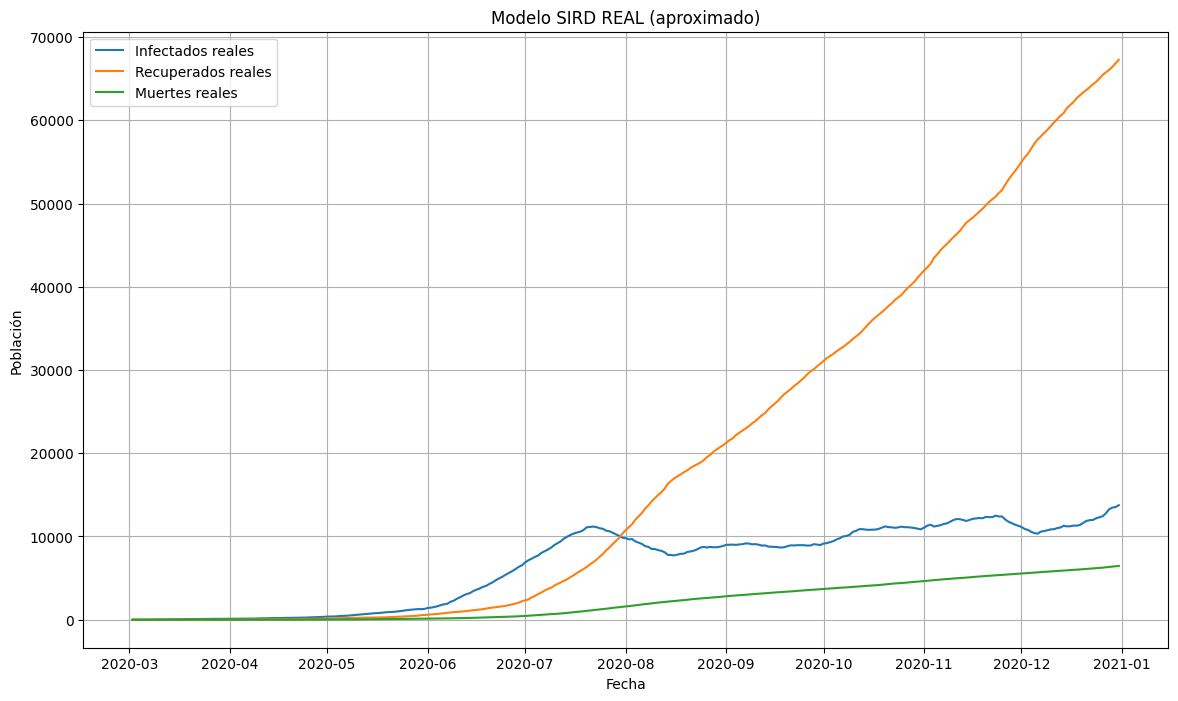

In [ ]:
# =========================================================
# GRÁFICA SIRD REAL
# =========================================================

plt.figure(figsize=(14,8))

plt.plot(
    fechas,
    I_real,
    label='Infectados reales'
)

plt.plot(
    fechas,
    R_real,
    label='Recuperados reales'
)

plt.plot(
    fechas,
    D_real,
    label='Muertes reales'
)

plt.title("Modelo SIRD REAL (aproximado)")

plt.xlabel("Fecha")

plt.ylabel("Población")

plt.legend()

plt.grid()

plt.show()

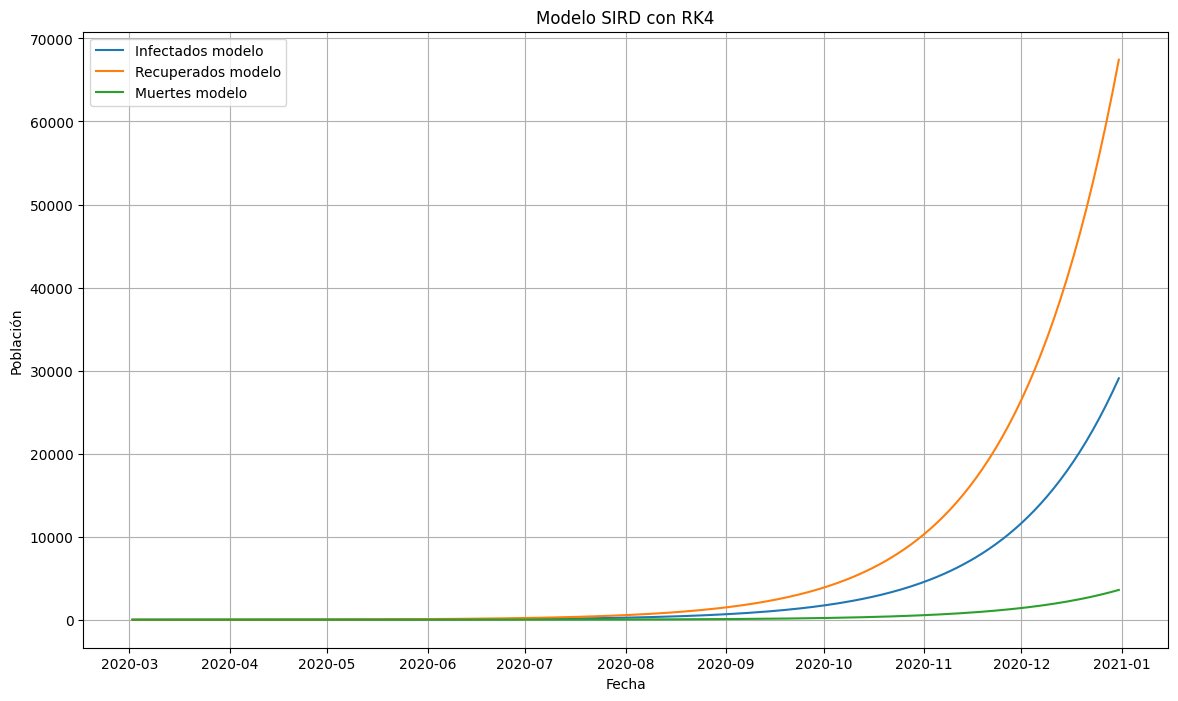

In [ ]:
# =========================================================
# GRÁFICA SIRD MODELADO
# =========================================================

plt.figure(figsize=(14,8))


plt.plot(
    fechas,
    I,
    label='Infectados modelo'
)

plt.plot(
    fechas,
    R,
    label='Recuperados modelo'
)

plt.plot(
    fechas,
    D,
    label='Muertes modelo'
)

plt.title("Modelo SIRD con RK4")

plt.xlabel("Fecha")

plt.ylabel("Población")

plt.legend()

plt.grid()

plt.show()

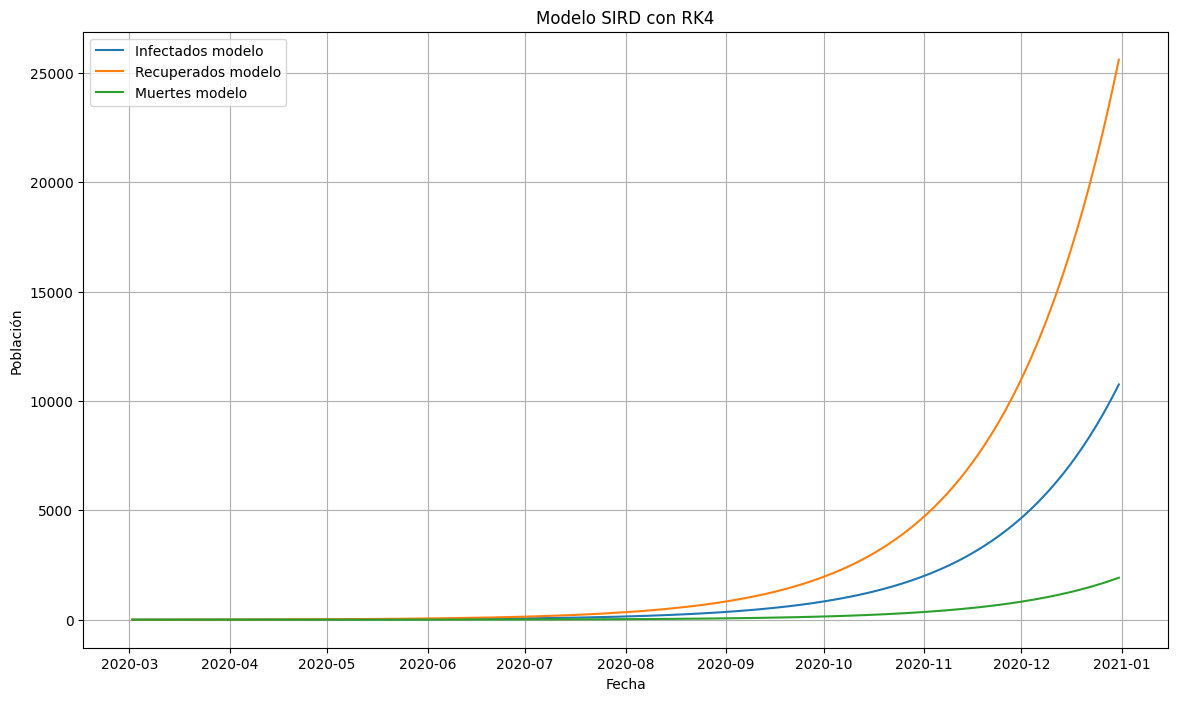

In [ ]:
# =========================================================
# GRÁFICA SIRD MODELADO
# =========================================================

plt.figure(figsize=(14,8))


plt.plot(
    fechas,
    I_b,
    label='Infectados modelo'
)

plt.plot(
    fechas,
    R_b,
    label='Recuperados modelo'
)

plt.plot(
    fechas,
    D_b,
    label='Muertes modelo'
)

plt.title("Modelo SIRD con RK4")

plt.xlabel("Fecha")

plt.ylabel("Población")

plt.legend()

plt.grid()

plt.show()